# Analyse this naive k curve - constant k

- get average endpoints, average hashes, average reductions

## Imports

In [2]:
import numpy as np
import pandas as pd

t = 10000

## Get data 

In [3]:
## cherry m values
cherry_m_values = []

# read in from each directory the m_values and append to cherry_m_values
for i in range(10):
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f't_{t}/trial_{i}/m_values.npy')
    cherry_m_values.append(m_values)


## vanilla m values
vanilla_m_values = []
for i in range(10):
    m_values = np.load(f'../vanilla/t_{t}/trial_{i}/m_values.npy')
    vanilla_m_values.append(m_values)

In [4]:
# create dataframe with columns "table", "avg. endpoints", "avg. hashes", "avg. reductions"
df = pd.DataFrame(columns=["table", "avg. endpoints", "avg. hashes", "avg. reductions"])

## get cherry data first
cherry_avg_mt = np.mean([cherry[-1] for cherry in cherry_m_values])
cherry_avg_hashes = np.mean([np.sum(cherry[:-1]) for cherry in cherry_m_values])
cherry_avg_reductions = np.mean([np.sum(cherry[:-1] * 100) for cherry in cherry_m_values])  # since k_i = 100
# df = df.concat({"table": "cherry", "avg. endpoints": cherry_avg_mt, "avg. hashes": cherry_avg_hashes, "avg. reductions": cherry_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "cherry", 
    "avg. endpoints": cherry_avg_mt, 
    "avg. hashes": cherry_avg_hashes, 
    "avg. reductions": cherry_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

## get vanilla data
vanilla_avg_mt = np.mean([vanilla[-1] for vanilla in vanilla_m_values])
vanilla_avg_hashes = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])
vanilla_avg_reductions = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])  # since k_i = 1
# df = df.append({"table": "vanilla", "avg. endpoints": vanilla_avg_mt, "avg. hashes": vanilla_avg_hashes, "avg. reductions": vanilla_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "vanilla", 
    "avg. endpoints": vanilla_avg_mt, 
    "avg. hashes": vanilla_avg_hashes, 
    "avg. reductions": vanilla_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

display(df)

C:\Users\psymf9\AppData\Local\Temp\ipykernel_46648\790874731.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


,table,avg. endpoints,avg. hashes,avg. reductions
0,cherry,11091.4,118328549.6,1.183285e+10
1,vanilla,2670.6,53882085.6,5.388209e+07


In [5]:
## total cost
total_cost_cherry = cherry_avg_hashes + (cherry_avg_reductions * 0.05)
total_cost_vanilla = vanilla_avg_hashes

print(f"Total cost of cherry: {total_cost_cherry}")
print(f"Total cost of vanilla: {total_cost_vanilla}")

print(total_cost_cherry / total_cost_vanilla)

Total cost of cherry: 709971297.6
Total cost of vanilla: 53882085.6
13.176388584334976


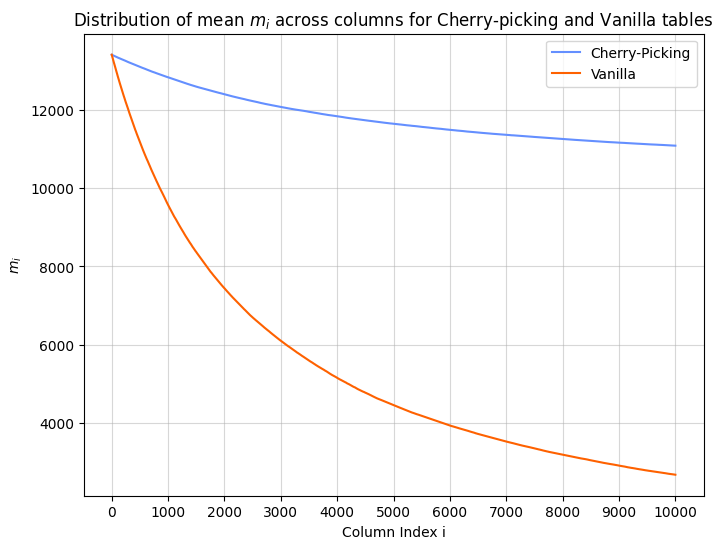

In [6]:
## Plot m_values for cherry and vanilla
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
# plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

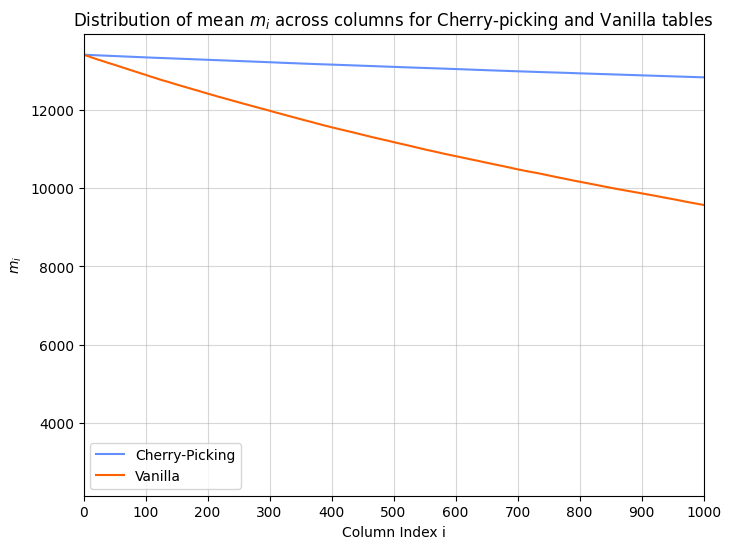

In [12]:
# graph but cut off at 1000

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(100))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)

# set x limit to 1000
plt.xlim(0, 1000)


plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
# plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

In [15]:
## what are the avergae points at t = 1000
print(f"Average m_i at index 1000 for cherry: {cherry_m_values_array[1000]}")
print(f"Average m_i at index 1000 for vanilla: {vanilla_m_values_array[1000]}")

# percentage difference between them
difference = cherry_m_values_array[1000] - vanilla_m_values_array[1000]
percentage_difference = (difference / vanilla_m_values_array[1000]) * 100
print(f"Percentage difference at index 1000: {percentage_difference:.2f}%")

Average m_i at index 1000 for cherry: 12840.6
Average m_i at index 1000 for vanilla: 9575.0
Percentage difference at index 1000: 34.11%


[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,

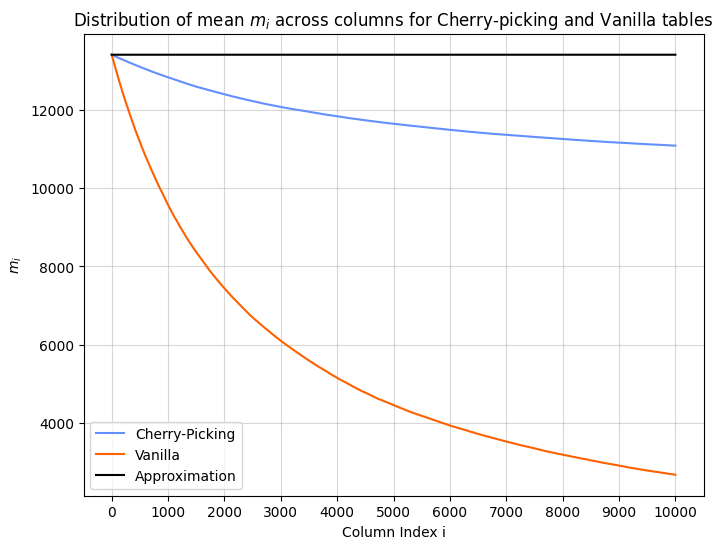

In [18]:
## add on approx
from math import sqrt, pi
from statistics import NormalDist

def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def get_mean(N, m):
    return N - (N * ((1 - 1/N) ** m))

def get_std(N, m):
    # E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m
    
    sqrt_term = (N * ((N - 1) * E2 + E1 - N * E1 ** 2))
    if (sqrt_term < 0):
        return 0
    else:
        return sqrt(sqrt_term)


def approx_mi(N, m, k):
    average = get_mean(N, m)
    sd = get_std(N, m)
    # make a normal distribution from these
    # s = np.random.normal(average, sd, k)
    # # sample k random values from this distribution and take the maximum
    # return max(s)

    m = min(m , average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd)
    # m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
    return m

# Table with the approximation of the occupancy problem
def table_approx(N, t, alpha, k_values):
    m0 = round(calculate_m0(N, t, alpha))
    print(f"m0: {m0}")
    m_values = [m0]
    m = m0

    for i in range(t):
        m = approx_mi(N, m, k_values[i])
        m_values.append(m)

    return m_values

## Plot m_values for cherry and vanilla

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)


# # plot on approx
k_values = [100] * t
print(k_values)
approx_m_values = table_approx(2**24, 10000, 0.8, [100] * t)
# append 9000 0s to the end of approx_m_values to make it the same length as cherry and vanilla m values
approx_m_values = approx_m_values + [0] * (t + 1 - len(approx_m_values))
plt.plot(x_indicies, approx_m_values, color='#000000', label="Approximation", markersize=5)


ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
# plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

m0: 3435287
m0: 3435287


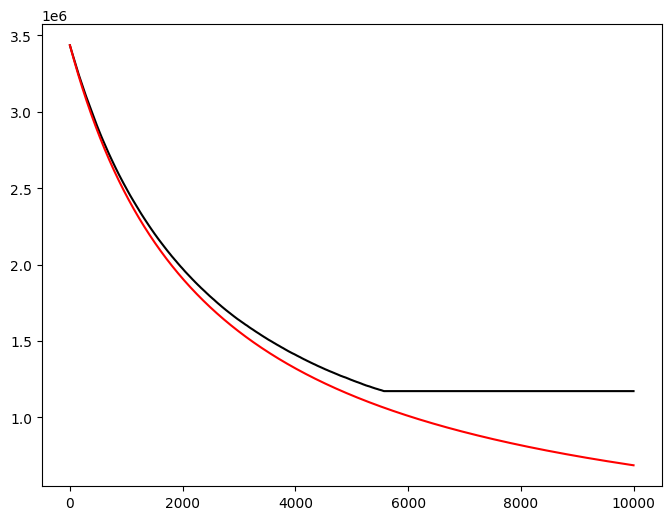

In [9]:
# plot approx for 2 ** 32
approx_m_Values = table_approx(2**32, 10000, 0.8, [100] * t)
approx_m_van = table_approx(2**32, 10000, 0.8, [1] * t)

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
plt.plot(x_indicies, approx_m_Values, color='#000000', label="Approximation", markersize=5)
plt.plot(x_indicies, approx_m_van, color='#FF0000', label="Approximation Vanilla", markersize=5)

plt.show()

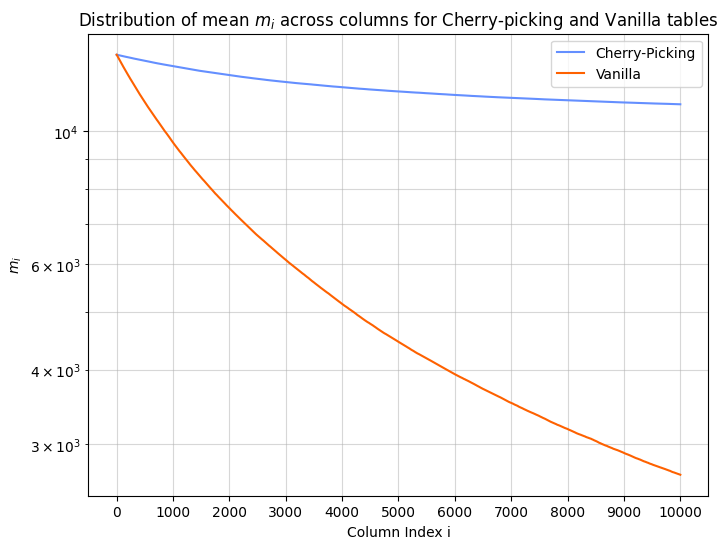

In [10]:
## Plot m_values for cherry and vanilla
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import LogLocator, LogFormatterMathtext

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

ax = plt.gca()
ax.set_yscale('log')

# Force ticks only at integer powers of 10 (e.g., 10^0, 10^1, 10^2)
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=10))
# Ensure they display nicely as 10^x
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)
# plt.grid(visible=True, which='major', axis='both', alpha=0.5)
# plt.grid(visible=True, which='minor', axis='y', alpha=0.2)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
# plt.savefig("m_values_distribution.eps", format='eps', bbox_inches='tight')
plt.show()

In [11]:
## success prob
ch_sp = 1 - ((1 - (cherry_avg_mt / 2**24)) ** t)
van_sp = 1 - ((1 - (vanilla_avg_mt / 2**24)) ** t)

print(f"Success probability of cherry: {ch_sp}")
print(f"Success probability of vanilla: {van_sp}")

Success probability of cherry: 0.9986574383265293
Success probability of vanilla: 0.7964672489933474
